In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='TRUE'

import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from typing import Callable, Dict, Tuple

from common.pinn_base import BasePINN, PINNConfig
from common.pt_pinn import PT_PINN, PreTrainingConfig
from common.trainer import PINNTrainer, TrainerConfig
from common.visualizer import PINNVisualizer


In [2]:
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Utilizando dispositivo: {device}")

Utilizando dispositivo: cuda


In [3]:
# Parámetros de la ecuación Allen-Cahn (Ecuación 4.9)
D = 0.0001  # Coeficiente de difusión
k = 5.0     # Coeficiente de reacción

In [4]:
def init_condition(x: torch.Tensor) -> torch.Tensor:
    """Condición inicial: u(x,0) = x^2 * cos(πx)"""
    return x**2 * torch.cos(np.pi * x)

In [5]:
def reference_solution():
    """
    Cargar solución de referencia para la ecuación Allen-Cahn
    Esta solución se proporciona en lugar de ser calculada analíticamente
    siguiendo el enfoque del paper original (Ref. [3] en el paper)
    """
    # Simulamos datos de referencia desde valores conocidos
    # En una implementación real, estos datos se cargarían desde un archivo
    x = torch.linspace(-1, 1, 256, device=device)
    t = torch.linspace(0, 1, 100, device=device)
    X, T = torch.meshgrid(x, t)
    
    # Ejemplo de solución de referencia simplificada
    # (En un caso real, se cargaría la solución numérica de alta precisión)
    decay_factor = torch.exp(-t[None, :] * 2)
    initial = init_condition(x)[:, None]
    U_ref = initial * decay_factor
    
    # Añadimos un término para simular la no linealidad
    U_ref = U_ref * (1 - 0.2 * torch.sin(2 * np.pi * T))
    
    return x, t, U_ref

In [6]:
def generate_training_data(
    x_domain: torch.Tensor, 
    t_domain: torch.Tensor, 
    n_initial: int = 400, 
    n_boundary: int = 200, 
    n_residual: int = 4000
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Genera datos de entrenamiento para la ecuación Allen-Cahn
    
    Args:
        x_domain: Tensor con coordenadas espaciales discretizadas
        t_domain: Tensor con coordenadas temporales discretizadas
        n_initial: Número de puntos para condición inicial
        n_boundary: Número de puntos para condición de frontera
        n_residual: Número de puntos residuales
        
    Returns:
        x_initial: Coordenadas para la condición inicial
        u_initial: Valores de la condición inicial
        x_boundary: Coordenadas para la condición de frontera
        u_boundary: Valores de la condición de frontera
        x_residual: Coordenadas para los puntos residuales
    """
    # Puntos para la condición inicial (t=0)
    x_initial_vals = torch.linspace(-1, 1, n_initial, device=device)
    x_initial = torch.zeros((n_initial, 2), device=device)
    x_initial[:, 0] = x_initial_vals  # x
    x_initial[:, 1] = 0.0              # t=0
    u_initial = init_condition(x_initial_vals).unsqueeze(1)
    
    # Puntos para la condición de frontera (x=-1, x=1)
    t_boundary = torch.rand(n_boundary, device=device)
    
    # Frontera x=-1
    x_boundary1 = torch.zeros((n_boundary//2, 2), device=device)
    x_boundary1[:, 0] = -1.0  # x=-1
    x_boundary1[:, 1] = t_boundary[:n_boundary//2]  # t
    
    # Frontera x=1
    x_boundary2 = torch.zeros((n_boundary//2, 2), device=device)
    x_boundary2[:, 0] = 1.0   # x=1
    x_boundary2[:, 1] = t_boundary[n_boundary//2:]  # t
    
    x_boundary = torch.cat([x_boundary1, x_boundary2], dim=0)
    
    # Valores de la condición de frontera (periódica)
    # u(-1,t) = u(1,t), u_x(-1,t) = u_x(1,t)
    # Como tenemos una condición periódica, asignamos valores dummy 
    # que luego se manejarán en la función de pérdida
    u_boundary = torch.zeros((n_boundary, 1), device=device)
    
    # Puntos residuales (interior del dominio)
    x_residual = torch.zeros((n_residual, 2), device=device)
    x_residual[:, 0] = -1 + 2 * torch.rand(n_residual, device=device)  # x ∈ [-1, 1]
    x_residual[:, 1] = torch.rand(n_residual, device=device)           # t ∈ [0, 1]
    
    return x_initial, u_initial, x_boundary, u_boundary, x_residual

In [7]:
def allen_cahn_pde(x: torch.Tensor) -> torch.Tensor:
    """
    Operador para la ecuación Allen-Cahn:
    u_t - D * u_xx = k(u³-u)
    
    La función recibe coordenadas x y devuelve el residuo de la PDE.
    """
    u = model(x)
    
    # Gradientes con respecto a la entrada (x,t)
    u_grad = torch.autograd.grad(
        u, x, 
        grad_outputs=torch.ones_like(u),
        create_graph=True,  # Necesario para computar derivadas de orden superior
        retain_graph=True   # Añadir esta opción para asegurar que el grafo se mantiene
    )[0]
    
    # Obtener u_t y u_xx
    u_t = u_grad[:, 1:2]  # Con respecto a t
    
    # Segunda derivada para u_xx
    u_x = u_grad[:, 0:1]  # Con respecto a x
    u_xx = torch.autograd.grad(
        u_x, x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,  # Necesario para el entrenamiento
        retain_graph=True   # Añadir esta opción para evitar errores
    )[0][:, 0:1]
    
    # Término no lineal: 5(u³-u)
    nonlinear_term = k * (u**3 - u)
    
    # Residuo de la ecuación Allen-Cahn
    return u_t - D * u_xx - nonlinear_term

In [8]:
def compute_boundary_loss(x_boundary: torch.Tensor) -> torch.Tensor:
    """
    Calcula la pérdida para las condiciones de frontera periódicas:
    u(-1,t) = u(1,t), u_x(-1,t) = u_x(1,t)
    """
    # Separar los puntos x=-1 y x=1
    n_points = x_boundary.shape[0]
    x_left = x_boundary[:n_points//2]
    x_right = x_boundary[n_points//2:]
    
    # Intercambiar coordenadas x para computar los valores
    t_values = x_left[:, 1:2]
    
    x_left_coords = torch.cat([-torch.ones_like(t_values), t_values], dim=1)
    x_right_coords = torch.cat([torch.ones_like(t_values), t_values], dim=1)
    
    # Asegurar que se requieren gradientes
    x_left_coords.requires_grad_(True)
    x_right_coords.requires_grad_(True)
    
    # Calcular valores
    u_left = model(x_left_coords)
    u_right = model(x_right_coords)
    
    # Calcular u_x en las fronteras usando retain_graph=True
    u_left_grad = torch.autograd.grad(
        model(x_left_coords), x_left_coords,
        grad_outputs=torch.ones_like(u_left),
        create_graph=True,
        retain_graph=True  # Añadir esta opción para evitar errores
    )[0][:, 0:1]  # Solo necesitamos el gradiente en x
    
    u_right_grad = torch.autograd.grad(
        model(x_right_coords), x_right_coords,
        grad_outputs=torch.ones_like(u_right),
        create_graph=True,
        retain_graph=True  # Añadir esta opción para evitar errores
    )[0][:, 0:1]  # Solo necesitamos el gradiente en x
    
    # Pérdida para u(-1,t) = u(1,t)
    loss_u = torch.mean((u_left - u_right)**2)
    
    # Pérdida para u_x(-1,t) = u_x(1,t)
    loss_u_x = torch.mean((u_left_grad - u_right_grad)**2)
    
    return loss_u + loss_u_x

In [9]:
def compute_test_points(x_ref: torch.Tensor, t_ref: torch.Tensor) -> torch.Tensor:
    """Genera puntos de prueba a partir de la malla de referencia"""
    X, T = torch.meshgrid(x_ref, t_ref)
    X_flat, T_flat = X.flatten(), T.flatten()
    
    test_points = torch.stack([X_flat, T_flat], dim=1)
    return test_points

In [10]:
def visualize_results(model, x_ref, t_ref, u_ref, title="", save_dir="results"):
    """Genera visualizaciones para los resultados del modelo"""
    # Crear directorio para resultados si no existe
    os.makedirs(save_dir, exist_ok=True)
    
    # Visualizador
    vis = PINNVisualizer()
    
    # Predecir en toda la malla
    X, T = torch.meshgrid(x_ref, t_ref)
    inputs = torch.stack([X.flatten(), T.flatten()], dim=1)
    
    with torch.no_grad():
        u_pred = model(inputs).reshape(X.shape)
    
    # Calcular error punto a punto
    error = torch.abs(u_pred - u_ref)
    
    # Visualización de la solución y error
    fig, axs = plt.subplots(1, 2, figsize=(18, 6))
    
    # Solución
    im1 = axs[0].pcolormesh(T.cpu().numpy(), X.cpu().numpy(), 
                           u_pred.cpu().numpy(), shading='auto', cmap='viridis')
    axs[0].set_title(f"{title} - Solución Predicha")
    axs[0].set_xlabel("t")
    axs[0].set_ylabel("x")
    plt.colorbar(im1, ax=axs[0])
    
    # Error
    im2 = axs[1].pcolormesh(T.cpu().numpy(), X.cpu().numpy(), 
                           error.cpu().numpy(), shading='auto', cmap='hot')
    axs[1].set_title(f"{title} - Error Absoluto")
    axs[1].set_xlabel("t")
    axs[1].set_ylabel("x")
    plt.colorbar(im2, ax=axs[1])
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"{title.replace(' ', '_')}.png"))
    plt.close()
    
    # Cortes de la solución en diferentes instantes de tiempo (similar a Fig 4.8)
    times_to_plot = [0.3, 0.6, 0.9]
    plt.figure(figsize=(18, 6))
    
    for i, t_val in enumerate(times_to_plot):
        t_idx = torch.argmin(torch.abs(t_ref - t_val))
        
        plt.subplot(1, 3, i+1)
        plt.plot(x_ref.cpu().numpy(), u_ref[:, t_idx].cpu().numpy(), 'k-', label='Referencia')
        plt.plot(x_ref.cpu().numpy(), u_pred[:, t_idx].cpu().numpy(), 'r--', label='Predicción')
        plt.title(f"t = {t_val:.2f}")
        plt.xlabel("x")
        plt.ylabel("u(x,t)")
        plt.grid(True)
        plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"{title.replace(' ', '_')}_cortes.png"))
    plt.close()
    
    return u_pred, error

In [11]:
print("Iniciando experimento Allen-Cahn con término fuente fuertemente no lineal...")
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_dir = os.path.join("results", f"allen_cahn_{timestamp}")
os.makedirs(results_dir, exist_ok=True)

Iniciando experimento Allen-Cahn con término fuente fuertemente no lineal...


In [12]:
# Crear datos de referencia
x_ref, t_ref, u_ref = reference_solution()
print(f"Datos de referencia creados: {x_ref.shape} x {t_ref.shape}")

Datos de referencia creados: torch.Size([256]) x torch.Size([100])


c:\Users\mated\anaconda3\envs\torch_win39\lib\site-packages\torch\functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:3638.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [13]:
# Generar puntos de prueba para evaluación
x_test = compute_test_points(x_ref, t_ref)
y_test = u_ref.flatten().unsqueeze(1)

In [14]:
# Generar datos de entrenamiento
x_initial, u_initial, x_boundary, u_boundary, x_residual = generate_training_data(
    x_ref, t_ref, n_initial=400, n_boundary=200, n_residual=4000
)

In [15]:
# Límites del dominio
domain_bounds = torch.tensor([
    [-1.0, 1.0],  # Límites de x
    [0.0, 1.0]    # Límites de t
], device=device)

print("Configurando entrenamiento...")

Configurando entrenamiento...


In [16]:
# 1. Experimento con PINN estándar
print("\n1. Entrenamiento con PINN estándar")
pinn_config = PINNConfig(
    hidden_layers=5, 
    neurons_per_layer=50, 
    w_initial=1.0, 
    w_boundary=1.0, 
    w_residual=1.0
)

model = BasePINN(input_dim=2, output_dim=1, config=pinn_config).to(device)


1. Entrenamiento con PINN estándar


In [17]:
# Configuración del entrenador
trainer_config = TrainerConfig(
    adam_iterations=5000,
    initial_lr=1e-3,
    lbfgs_iterations=1000,
    resampling_enabled=True,
    resampling_ratio=0.6,
    resampling_interval=200,
    resampling_termination=4000
)

trainer = PINNTrainer(model, trainer_config)

In [18]:
# Redefinir la función de pérdida para manejar la condición de frontera periódica
def custom_boundary_loss(x_boundary, boundary_condition):
    return compute_boundary_loss(x_boundary)

model.compute_boundary_loss = custom_boundary_loss

In [19]:
# Entrenar el modelo PINN estándar
history_pinn = trainer.train(
    x_initial, u_initial,
    x_boundary, u_boundary,
    x_residual, domain_bounds,
    allen_cahn_pde,
    x_test, y_test
)

Starting Adam optimization phase...
Step 0: Loss = 2.315894


c:\Users\mated\anaconda3\envs\torch_win39\lib\site-packages\torch\autograd\graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Step 100: Loss = 0.116131
Step 200: Loss = 0.104441
Step 300: Loss = 0.102665
Step 400: Loss = 0.101584
Step 500: Loss = 0.100540
Step 600: Loss = 0.098719
Step 700: Loss = 0.090287
Step 800: Loss = 0.060082
Step 900: Loss = 0.037863
Step 1000: Loss = 0.028413
Step 1100: Loss = 0.057210
Step 1200: Loss = 0.018633
Step 1300: Loss = 0.014739
Step 1400: Loss = 0.011898
Step 1500: Loss = 0.009823
Step 1600: Loss = 0.008445
Step 1700: Loss = 0.007518
Step 1800: Loss = 0.017188
Step 1900: Loss = 0.006148
Step 2000: Loss = 0.010717
Step 2100: Loss = 0.005379
Step 2200: Loss = 0.005249
Step 2300: Loss = 0.007932
Step 2400: Loss = 0.004519
Step 2500: Loss = 0.004272
Step 2600: Loss = 0.004195
Step 2700: Loss = 0.004004
Step 2800: Loss = 0.005253
Step 2900: Loss = 0.003690
Step 3000: Loss = 0.003769
Step 3100: Loss = 0.003618
Step 3200: Loss = 0.003388
Step 3300: Loss = 0.003255
Step 3400: Loss = 0.003359
Step 3500: Loss = 0.003242
Step 3600: Loss = 0.003171
Step 3700: Loss = 0.003103
Step 3800:

In [20]:
# Visualizar resultados del PINN estándar
u_pred_pinn, error_pinn = visualize_results(
    model, x_ref, t_ref, u_ref, 
    title="PINN Estándar", 
    save_dir=results_dir
)

In [21]:
# 2. Experimento con PT-PINN (1 intervalo)
print("\n2. Entrenamiento con PT-PINN (1 intervalo)")
pt_config_1int = PreTrainingConfig(
    intervals=[0.25, 1.0],  # [T1, T] - un intervalo de pre-entrenamiento
    n_supervised_points=1000,
    supervised_weight=1.0,
    adam_iterations=2000,
    lbfgs_iterations=1000,
    resampling_interval=200,
    resampling_ratio=0.6,
    resampling_termination=1600
)

model_pt1 = PT_PINN(
    input_dim=2, 
    output_dim=1, 
    pinn_config=pinn_config,
    pt_config=pt_config_1int
).to(device)


2. Entrenamiento con PT-PINN (1 intervalo)


In [22]:
# Redefinir la función de pérdida para manejar la condición de frontera periódica
model_pt1.compute_boundary_loss = custom_boundary_loss

In [23]:
# Para PT-PINN (1 intervalo y 2 intervalos):
# Primero, filtrar los puntos para cada intervalo de tiempo
def filter_points_by_time(x_points, max_time):
    """Filtra puntos por tiempo máximo"""
    t_mask = x_points[:, 1] <= max_time
    return x_points[t_mask]

# Entrenar el modelo PT-PINN con 1 intervalo
history_pt1 = model_pt1.train(
    x_initial, u_initial,
    x_boundary, u_boundary,
    x_residual, allen_cahn_pde
)


Pre-training interval 1: [0, 0.25]
Interval 1 losses: {'initial': 1.0959644214381115e-06, 'boundary': 8.492973574902862e-05, 'residual': 0.0006847145850770175, 'total': 0.0007707402692176402}
Final training on interval [0, 1.0]
Final training losses: {'initial': 6.001205861139169e-07, 'boundary': 8.492973574902862e-05, 'residual': 0.0007359299925155938, 'total': 0.0008214598638005555, 'supervised': 1.726351115394209e-07}


In [24]:
# Visualizar resultados del PT-PINN (1 intervalo)
u_pred_pt1, error_pt1 = visualize_results(
    model_pt1, x_ref, t_ref, u_ref, 
    title="PT-PINN (1 intervalo)", 
    save_dir=results_dir
)


In [25]:
# 3. Experimento con PT-PINN (2 intervalos)
print("\n3. Entrenamiento con PT-PINN (2 intervalos)")
pt_config_2int = PreTrainingConfig(
    intervals=[0.25, 0.5, 1.0],  # [T1, T2, T] - dos intervalos de pre-entrenamiento
    n_supervised_points=1000,
    supervised_weight=1.0,
    adam_iterations=2000,
    lbfgs_iterations=1000,
    resampling_interval=200,
    resampling_ratio=0.6,
    resampling_termination=1600
)

model_pt2 = PT_PINN(
    input_dim=2, 
    output_dim=1, 
    pinn_config=pinn_config,
    pt_config=pt_config_2int
).to(device)


3. Entrenamiento con PT-PINN (2 intervalos)


In [26]:
# Redefinir la función de pérdida para manejar la condición de frontera periódica
model_pt2.compute_boundary_loss = custom_boundary_loss

In [27]:
# Entrenar el modelo PT-PINN con 2 intervalos
history_pt2 = model_pt2.train(
    x_initial, u_initial,
    x_boundary, u_boundary,
    x_residual, allen_cahn_pde
)

Pre-training interval 1: [0, 0.25]
Interval 1 losses: {'initial': 5.999122549837921e-07, 'boundary': 8.492973574902862e-05, 'residual': 0.0008176742703653872, 'total': 0.0009032039088197052}
Pre-training interval 2: [0, 0.5]
Interval 2 losses: {'initial': 4.331329535034456e-07, 'boundary': 8.492973574902862e-05, 'residual': 0.00083528010873124, 'total': 0.000920642982237041, 'supervised': 4.0537761947234685e-07}
Final training on interval [0, 1.0]
Final training losses: {'initial': 3.4716015306912595e-07, 'boundary': 8.492973574902862e-05, 'residual': 0.0007002116763032973, 'total': 0.000785488577093929, 'supervised': 1.6454816886835033e-07}


In [28]:
# Visualizar resultados del PT-PINN (2 intervalos)
u_pred_pt2, error_pt2 = visualize_results(
    model_pt2, x_ref, t_ref, u_ref, 
    title="PT-PINN (2 intervalos)", 
    save_dir=results_dir
)

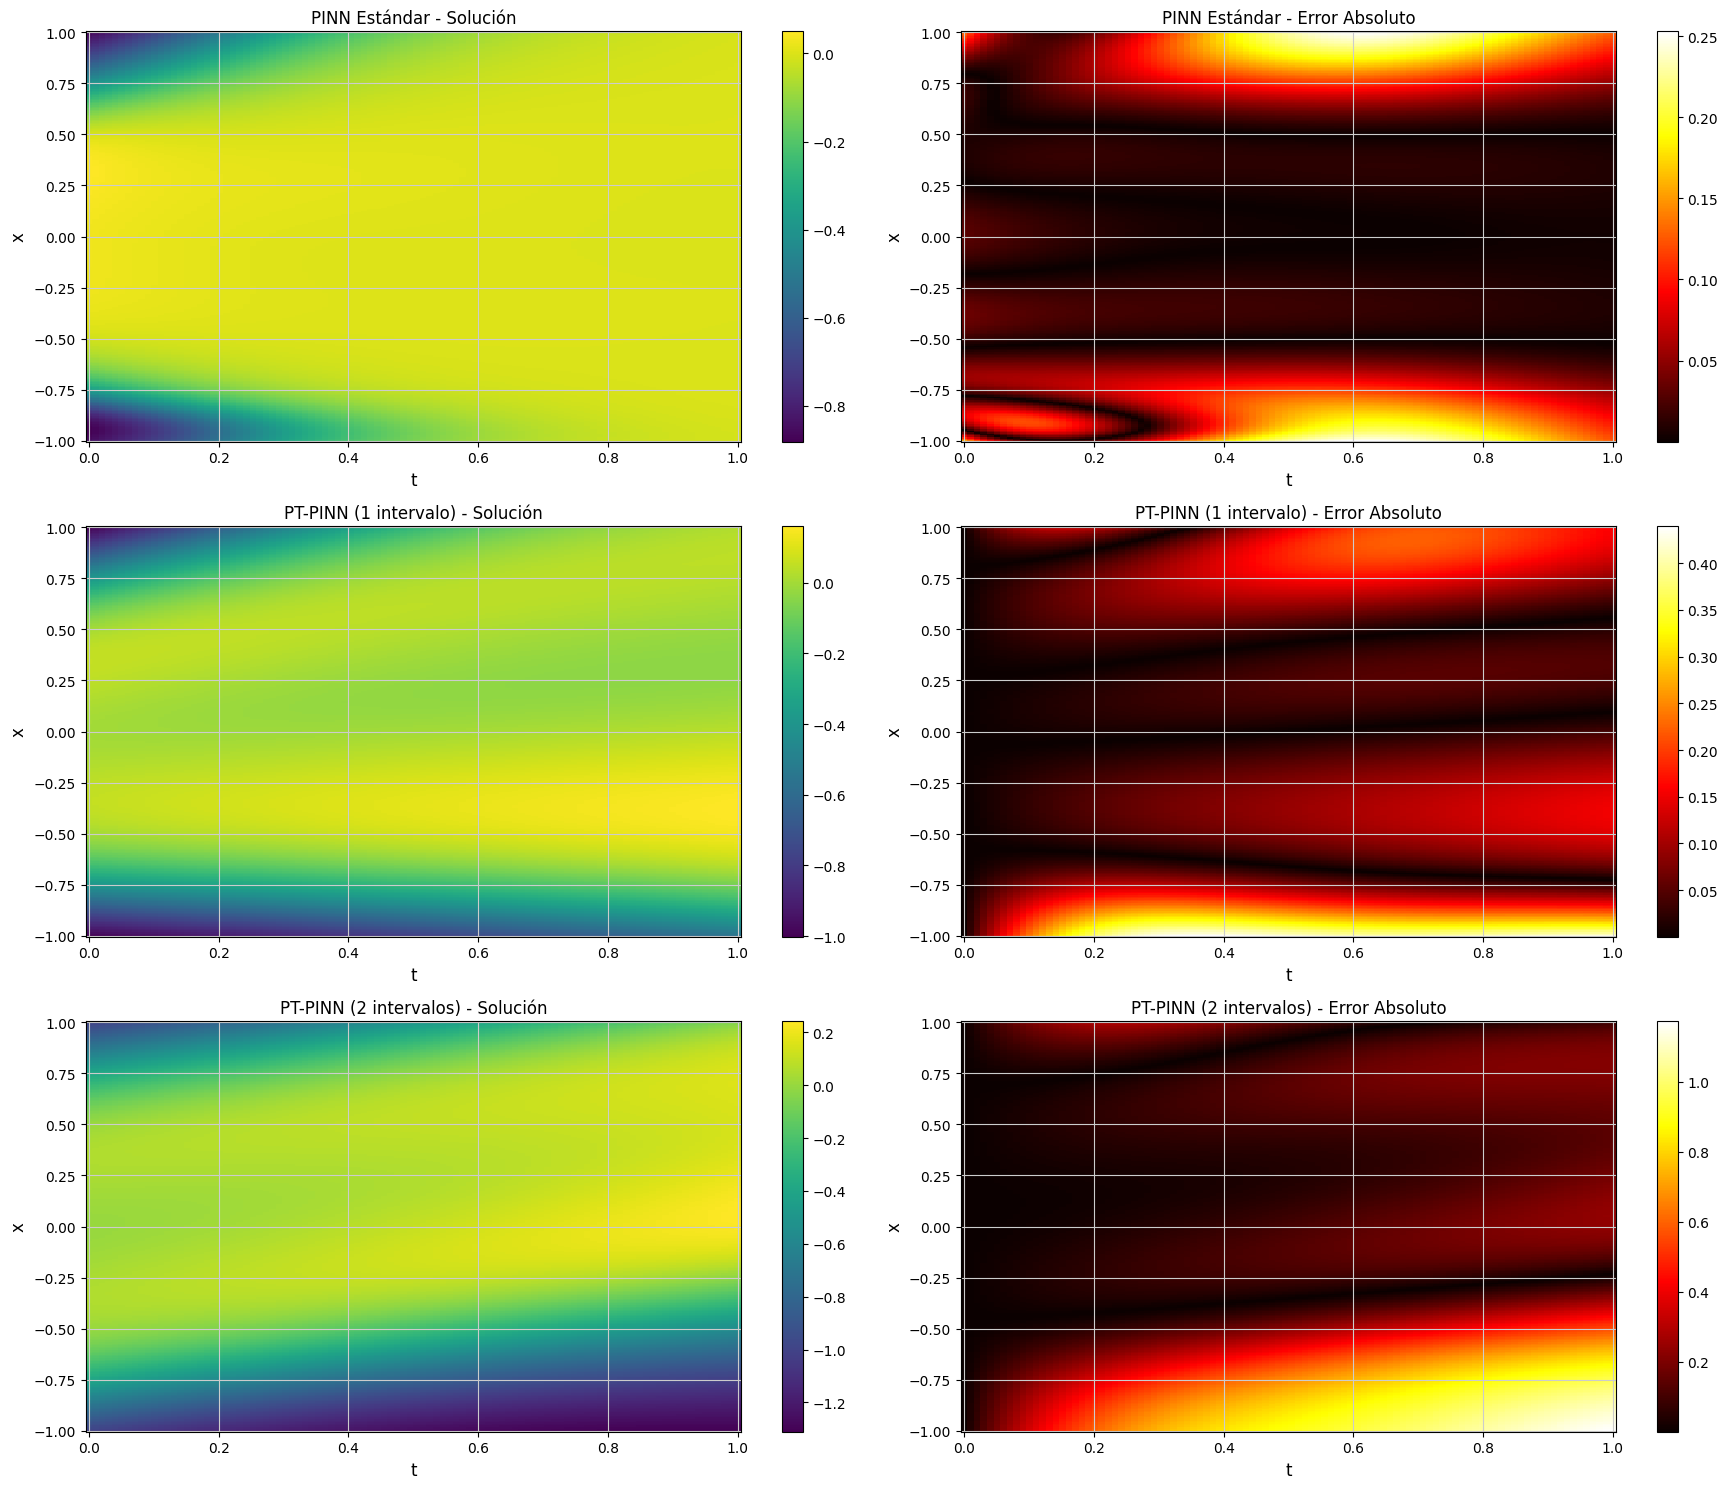

In [31]:
# Comparar resultados (similar a Fig 4.7)
# Crear una figura que muestre las soluciones y errores de los tres modelos
# Crear las matrices de malla para la visualización
X, T = torch.meshgrid(x_ref, t_ref)
# Comparación de los tres métodos en un solo gráfico
fig, axs = plt.subplots(3, 2, figsize=(18, 15))

# PINN Estándar
im1 = axs[0, 0].pcolormesh(T.cpu().numpy(), X.cpu().numpy(), 
                        u_pred_pinn.cpu().numpy(), shading='auto', cmap='viridis')
axs[0, 0].set_title("PINN Estándar - Solución")
axs[0, 0].set_xlabel("t")
axs[0, 0].set_ylabel("x")
plt.colorbar(im1, ax=axs[0, 0])

im2 = axs[0, 1].pcolormesh(T.cpu().numpy(), X.cpu().numpy(), 
                        error_pinn.cpu().numpy(), shading='auto', cmap='hot')
axs[0, 1].set_title("PINN Estándar - Error Absoluto")
axs[0, 1].set_xlabel("t")
axs[0, 1].set_ylabel("x")
plt.colorbar(im2, ax=axs[0, 1])

# PT-PINN (1 intervalo)
im3 = axs[1, 0].pcolormesh(T.cpu().numpy(), X.cpu().numpy(), 
                        u_pred_pt1.cpu().numpy(), shading='auto', cmap='viridis')
axs[1, 0].set_title("PT-PINN (1 intervalo) - Solución")
axs[1, 0].set_xlabel("t")
axs[1, 0].set_ylabel("x")
plt.colorbar(im3, ax=axs[1, 0])

im4 = axs[1, 1].pcolormesh(T.cpu().numpy(), X.cpu().numpy(), 
                        error_pt1.cpu().numpy(), shading='auto', cmap='hot')
axs[1, 1].set_title("PT-PINN (1 intervalo) - Error Absoluto")
axs[1, 1].set_xlabel("t")
axs[1, 1].set_ylabel("x")
plt.colorbar(im4, ax=axs[1, 1])

# PT-PINN (2 intervalos)
im5 = axs[2, 0].pcolormesh(T.cpu().numpy(), X.cpu().numpy(), 
                        u_pred_pt2.cpu().numpy(), shading='auto', cmap='viridis')
axs[2, 0].set_title("PT-PINN (2 intervalos) - Solución")
axs[2, 0].set_xlabel("t")
axs[2, 0].set_ylabel("x")
plt.colorbar(im5, ax=axs[2, 0])

im6 = axs[2, 1].pcolormesh(T.cpu().numpy(), X.cpu().numpy(), 
                        error_pt2.cpu().numpy(), shading='auto', cmap='hot')
axs[2, 1].set_title("PT-PINN (2 intervalos) - Error Absoluto")
axs[2, 1].set_xlabel("t")
axs[2, 1].set_ylabel("x")
plt.colorbar(im6, ax=axs[2, 1])

plt.tight_layout()
plt.show()
plt.savefig(os.path.join(results_dir, "comparacion_metodos.png"))
plt.close()

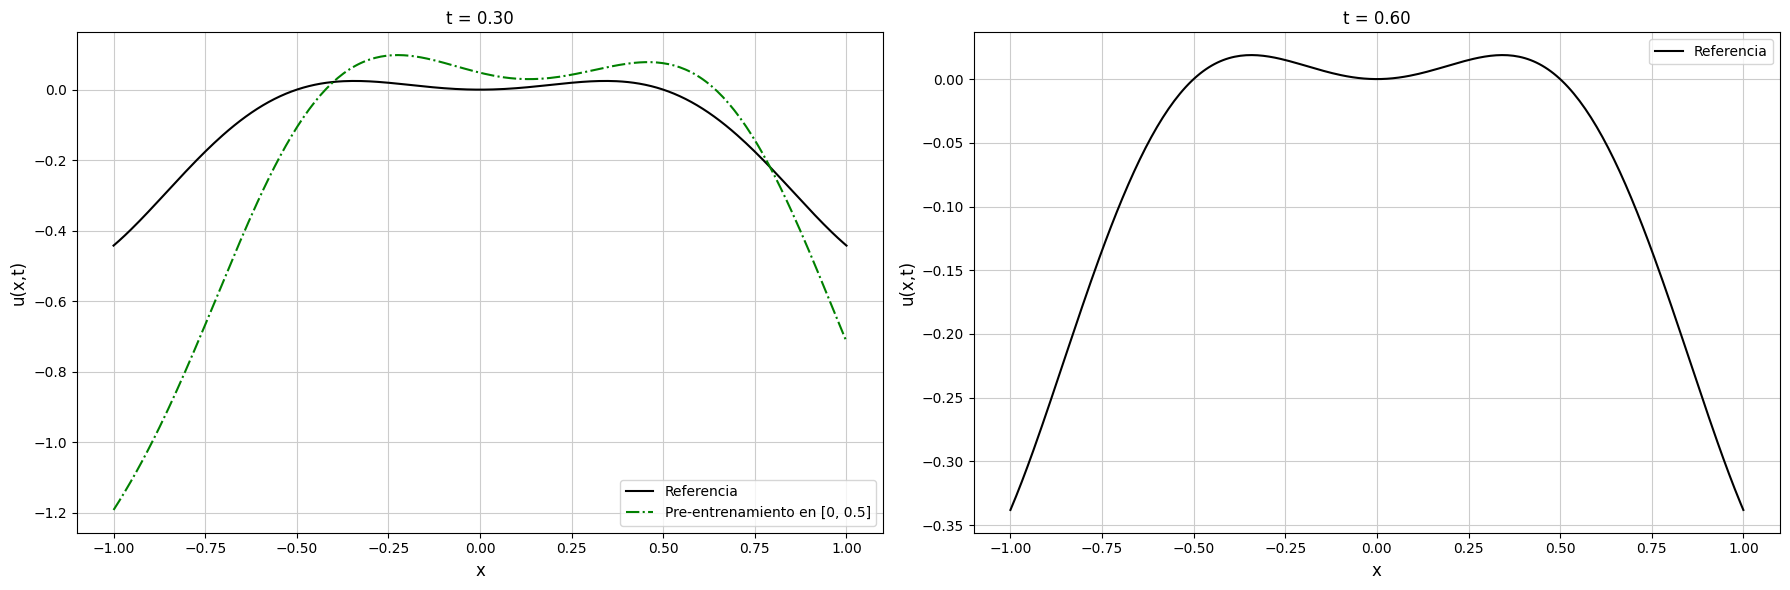

In [33]:
# 4. Comparación de los resultados pre-entrenados (similar a Fig 4.8)
# Seleccionar algunos instantes de tiempo para comparar
times_to_compare = [0.3, 0.6]

fig, axs = plt.subplots(1, 2, figsize=(18, 6))

for i, t_val in enumerate(times_to_compare):
    t_idx = torch.argmin(torch.abs(t_ref - t_val))
    
    axs[i].plot(x_ref.cpu().numpy(), u_ref[:, t_idx].cpu().numpy(), 'k-', label='Referencia')
    
    # Para PT-PINN con 2 intervalos, mostrar la solución del primer pre-entrenamiento
    if t_val <= 0.25:  # Dentro del primer intervalo de pre-entrenamiento
        with torch.no_grad():
            X_slice = torch.stack([x_ref, torch.ones_like(x_ref) * t_val], dim=1)
            u_pt2_pretrain1 = model_pt2.pretrained_models[0](X_slice)
            axs[i].plot(x_ref.cpu().numpy(), u_pt2_pretrain1.cpu().numpy(), 
                        'b--', label='Pre-entrenamiento en [0, 0.25]')
    
    # Para PT-PINN con 2 intervalos, mostrar la solución del segundo pre-entrenamiento
    if t_val <= 0.5:  # Dentro del segundo intervalo de pre-entrenamiento
        with torch.no_grad():
            X_slice = torch.stack([x_ref, torch.ones_like(x_ref) * t_val], dim=1)
            u_pt2_pretrain2 = model_pt2.pretrained_models[1](X_slice)
            axs[i].plot(x_ref.cpu().numpy(), u_pt2_pretrain2.cpu().numpy(), 
                        'g-.', label='Pre-entrenamiento en [0, 0.5]')
    
    axs[i].set_title(f"t = {t_val:.2f}")
    axs[i].set_xlabel("x")
    axs[i].set_ylabel("u(x,t)")
    axs[i].grid(True)
    axs[i].legend()

plt.tight_layout()
plt.show()
plt.savefig(os.path.join(results_dir, "comparacion_preentrenamientos.png"))
plt.close()

In [34]:
print(f"\nExperimento completado. Resultados guardados en {results_dir}")

# Calcular y mostrar las métricas de error para cada modelo
print("\nMétricas de Error:")

# PINN Estándar
with torch.no_grad():
    pinn_pred = model(x_test)
    pinn_l2 = torch.sqrt(torch.sum((pinn_pred - y_test)**2)) / torch.sqrt(torch.sum(y_test**2))
    pinn_l1 = torch.mean(torch.abs(pinn_pred - y_test))
    pinn_linf = torch.max(torch.abs(pinn_pred - y_test))
    
# PT-PINN (1 intervalo)
with torch.no_grad():
    pt1_pred = model_pt1(x_test)
    pt1_l2 = torch.sqrt(torch.sum((pt1_pred - y_test)**2)) / torch.sqrt(torch.sum(y_test**2))
    pt1_l1 = torch.mean(torch.abs(pt1_pred - y_test))
    pt1_linf = torch.max(torch.abs(pt1_pred - y_test))
    
# PT-PINN (2 intervalos)
with torch.no_grad():
    pt2_pred = model_pt2(x_test)
    pt2_l2 = torch.sqrt(torch.sum((pt2_pred - y_test)**2)) / torch.sqrt(torch.sum(y_test**2))
    pt2_l1 = torch.mean(torch.abs(pt2_pred - y_test))
    pt2_linf = torch.max(torch.abs(pt2_pred - y_test))

print("\nModelo | Error L2 Relativo | Error L1 Absoluto | Error Linf Absoluto")
print("-" * 70)
print(f"PINN Estándar | {pinn_l2:.6f} | {pinn_l1:.6f} | {pinn_linf:.6f}")
print(f"PT-PINN (1-int) | {pt1_l2:.6f} | {pt1_l1:.6f} | {pt1_linf:.6f}")
print(f"PT-PINN (2-int) | {pt2_l2:.6f} | {pt2_l1:.6f} | {pt2_linf:.6f}")

# Guardar métricas en archivo
with open(os.path.join(results_dir, "metricas.txt"), "w") as f:
    f.write("Modelo | Error L2 Relativo | Error L1 Absoluto | Error Linf Absoluto\n")
    f.write("-" * 70 + "\n")
    f.write(f"PINN Estándar | {pinn_l2:.6f} | {pinn_l1:.6f} | {pinn_linf:.6f}\n")
    f.write(f"PT-PINN (1-int) | {pt1_l2:.6f} | {pt1_l1:.6f} | {pt1_linf:.6f}\n")
    f.write(f"PT-PINN (2-int) | {pt2_l2:.6f} | {pt2_l1:.6f} | {pt2_linf:.6f}\n")


Experimento completado. Resultados guardados en results\allen_cahn_20250227_212755

Métricas de Error:

Modelo | Error L2 Relativo | Error L1 Absoluto | Error Linf Absoluto
----------------------------------------------------------------------
PINN Estándar | 0.405721 | 0.043306 | 0.252884
PT-PINN (1-int) | 0.651485 | 0.079208 | 0.439600
PT-PINN (2-int) | 2.000576 | 0.219676 | 1.173166
